# Laboratory practice 3.2: Regression II

For this practice, you will need the following datasets:

- **TemperaturesSpainSmall.csv**: dataset containing weather related data with the objective to predice the minimum temperature of Madrid Retiro (station 230).
    - WEEKDAY: day of the week
    - MONTH: month of the year
    - TMIN230: minimum temperature of station 230 (output)
    - TMAX230: maximum temperature of station 230 
    - TMAX229: maximum temperature of station 229
    - TMAX237: maximum temperature of station 237
    - TMAX417: maximum temperature of station 417
    - TMAX2969: maximum temperature of station 2969
    - TMAX3910: maximum temperature of station 3910
    - TMAX3918: maximum temperature of station 3918
    - TMAX3959: maximum temperature of station 3959

The main package for machine learning in Python is **scikit-learn**.

Further reading:
- [scikit-learn](https://scikit-learn.org)

In addition, we will be using the following libraries:
- Data management
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)

- Plotting
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)

- Model analysis
    - MLTools
    - [scipy](https://scipy.org/)

In [97]:
### Load libraries ###

# interactive plotting
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine learning libraries
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn import set_config
set_config(display='diagram')

# others
import math
from utils_student import *

---
## 1. Preparing the dataset

In [30]:
# Load data
df = pd.read_csv("TemperaturesSpain.csv", sep=";")
df.head()

,WEEKDAY,MONTH,TMIN230,TMAX230,TMAX229,TMAX237,TMAX417,TMAX2969,TMAX3910,TMAX3918,TMAX3959
0,3,1,5.6,7.4,13.4,16.5,21.6,14.2,13.2,16.2,20.8
1,4,1,4.9,9.0,12.0,11.2,19.7,11.6,14.0,15.4,19.2
2,5,1,2.5,10.5,11.0,13.0,20.5,14.6,14.4,16.2,19.6
3,6,1,3.4,10.4,13.2,15.6,18.0,14.4,16.0,15.6,19.6
4,7,1,2.6,8.5,14.8,17.0,22.5,13.8,13.2,15.6,21.5


In [32]:
#Info and type of variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   WEEKDAY   999 non-null    int64  
 1   MONTH     999 non-null    int64  
 2   TMIN230   999 non-null    float64
 3   TMAX230   999 non-null    float64
 4   TMAX229   999 non-null    float64
 5   TMAX237   999 non-null    float64
 6   TMAX417   999 non-null    float64
 7   TMAX2969  999 non-null    float64
 8   TMAX3910  999 non-null    float64
 9   TMAX3918  999 non-null    float64
 10  TMAX3959  999 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 86.0 KB


In [34]:
# Remove missing
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   WEEKDAY   999 non-null    int64  
 1   MONTH     999 non-null    int64  
 2   TMIN230   999 non-null    float64
 3   TMAX230   999 non-null    float64
 4   TMAX229   999 non-null    float64
 5   TMAX237   999 non-null    float64
 6   TMAX417   999 non-null    float64
 7   TMAX2969  999 non-null    float64
 8   TMAX3910  999 non-null    float64
 9   TMAX3918  999 non-null    float64
 10  TMAX3959  999 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 86.0 KB


In [36]:
# Data types
df.describe()

,WEEKDAY,MONTH,TMIN230,TMAX230,TMAX229,TMAX237,TMAX417,TMAX2969,TMAX3910,TMAX3918,TMAX3959
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,4.005005,6.105105,10.356657,20.454354,24.322523,22.433634,24.241642,20.287588,17.562863,22.304505,23.932533
std,1.999743,3.305119,6.981241,9.211738,8.781122,6.108889,3.069278,5.954193,4.667554,6.614032,3.437818
min,1.000000,1.000000,-3.600000,2.200000,5.200000,7.800000,18.000000,0.000000,6.400000,10.200000,17.500000
25%,2.000000,3.000000,4.700000,12.350000,16.900000,17.200000,21.500000,15.200000,13.800000,16.400000,20.900000
50%,4.000000,6.000000,9.300000,19.200000,23.600000,22.300000,24.000000,20.100000,17.600000,21.400000,23.700000
75%,6.000000,9.000000,16.250000,28.600000,31.800000,27.700000,26.500000,25.650000,21.600000,28.600000,26.400000
max,7.000000,12.000000,25.300000,39.400000,42.800000,37.000000,37.800000,33.800000,31.800000,38.200000,38.600000


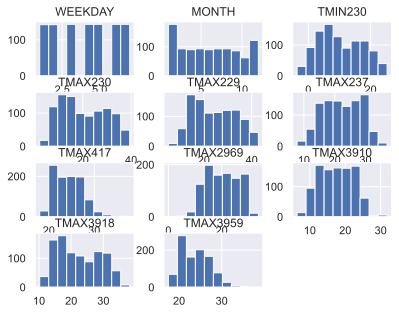

In [38]:
df.hist()
plt.show()

In [40]:
### Convert necessary variable to factor
df.WEEKDAY = df.WEEKDAY.astype('category')
df.MONTH = df.MONTH.astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   WEEKDAY   999 non-null    category
 1   MONTH     999 non-null    category
 2   TMIN230   999 non-null    float64 
 3   TMAX230   999 non-null    float64 
 4   TMAX229   999 non-null    float64 
 5   TMAX237   999 non-null    float64 
 6   TMAX417   999 non-null    float64 
 7   TMAX2969  999 non-null    float64 
 8   TMAX3910  999 non-null    float64 
 9   TMAX3918  999 non-null    float64 
 10  TMAX3959  999 non-null    float64 
dtypes: category(2), float64(9)
memory usage: 73.1 KB


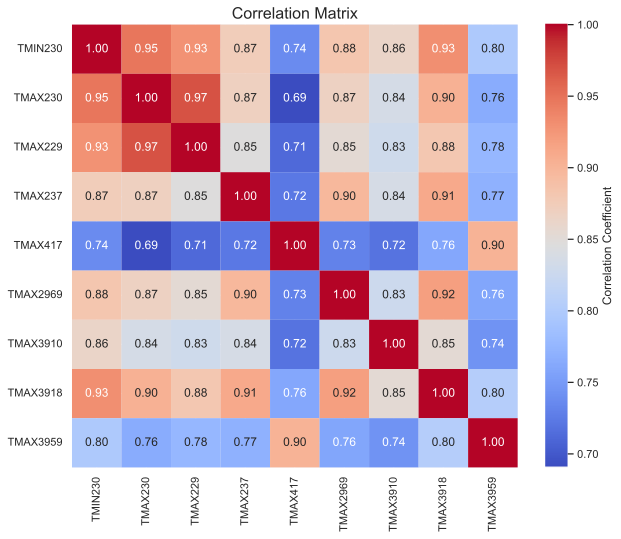

In [42]:
### Exploratory analysis -------------------------------------------------------------------------------------
#correlation plot of numeric variables
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Create a correlation matrix
corr_matrix = numeric_cols.corr()

# Set the plot size
plt.figure(figsize=(10, 8))

# Create a heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})

# Set the title
plt.title('Correlation Matrix', fontsize=16)

# Display the plot
plt.show()

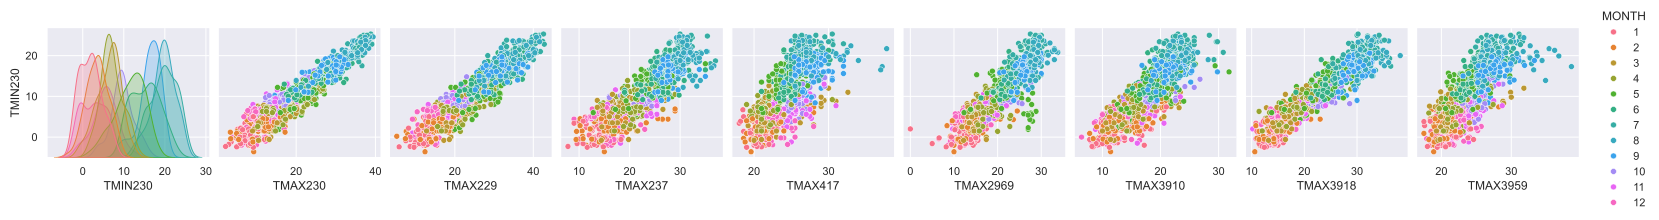

In [44]:
#To analyze in greater detail the relation between inputs and output, use PlotDataframe function
sns.pairplot(data=df, y_vars=['TMIN230'], hue='MONTH') ## hue es para colorear el gráfico segun variables categóricas.
plt.show()

In [46]:
# Define input and output matrices
INPUTS = df.columns[df.columns != 'TMIN230']
OUTPUT = 'TMIN230'

# We have categorical inputs with many classes. We will create dummy variables automatically after
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0) #seed for replication
X_train.head()

,WEEKDAY,MONTH,TMAX230,TMAX229,TMAX237,TMAX417,TMAX2969,TMAX3910,TMAX3918,TMAX3959
615,2,9,31.0,31.8,29.5,28.5,27.0,23.2,29.4,26.6
949,7,8,28.0,27.6,30.0,26.5,29.5,19.8,36.0,27.0
864,6,5,30.6,34.0,22.3,23.0,21.0,18.4,28.0,25.9
821,5,4,12.5,18.0,21.0,21.3,19.8,15.2,20.2,21.9
634,7,9,14.6,22.6,26.3,27.0,24.4,19.0,28.0,26.2


In [48]:
## Create dataset to store model predictions
dfTR_eval = X_train.copy()
dfTR_eval['TMIN230'] = y_train
dfTS_eval = X_test.copy()
dfTS_eval['TMIN230'] = y_test

---
## 2. Training of Machine Learning model

#### Simple model

In [65]:
## Inputs of the model. Change accordingly to perform variable selection
#Estamos usando todas las variables
INPUTS_LR_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_LR_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_LR = INPUTS_LR_NUM + INPUTS_LR_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_LR_NUM),
        ('cat', categorical_transformer, INPUTS_LR_CAT)
        ])

param = {} 
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('LR_model', LinearRegression(fit_intercept=True))
        ])
# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
LR_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='neg_mean_squared_error', # RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
LR_fit.fit(X_train[INPUTS_LR], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('LR_model', LinearRegression())]),
             n_jobs=-1, param_grid={}, scoring='neg_mean_squared_error')

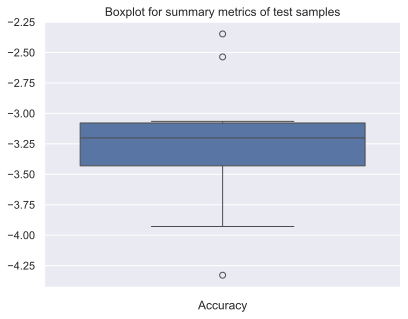

In [67]:
# Plot the cross validation score (accuracy) in the Grid Search
cv_errors = np.empty([nFolds,len(LR_fit.cv_results_['split0_test_score'])])
for split in range(nFolds):
    cv_errors[split,:] = LR_fit.cv_results_['split' + str(split) + '_test_score']
meanAcc = cv_errors.mean(0)
stdAcc = cv_errors.std(0)

scores_LR1 = meanAcc # Store cv-scores for later

ax = sns.boxplot(y=cv_errors.squeeze()).set_title('Boxplot for summary metrics of test samples')
plt.xlabel('Accuracy')
plt.show()

In [69]:
#Aquí estamos usando todas las variables
# transform the input variables
X_train_pre = LR_fit.best_estimator_['preprocessor'].fit_transform(X_train[INPUTS_LR_NUM + INPUTS_LR_CAT])
# add constant
X_train_pre = sm.add_constant(X_train_pre)
# fit the model
model = sm.OLS(y_train, X_train_pre).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                TMIN230   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     495.8
Date:                Wed, 23 Oct 2024   Prob (F-statistic):               0.00
Time:                        09:22:49   Log-Likelihood:                -1573.8
No. Observations:                 799   AIC:                             3198.
Df Residuals:                     774   BIC:                             3315.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.6074      0.053    161.691      0.0

In [71]:
# Obtain names of input variables including dummy variables
X_processed = LR_fit.best_estimator_[0].transform(X_train)
if X_train.select_dtypes('category').shape[1] > 0:
    column_init = X_train.select_dtypes(exclude='category').shape[1]
    input_names = []
    for cat_input in X_train.select_dtypes('category').columns:
        input_names += [cat_input + str(cat) for cat in X_train[cat_input].unique()]
        input_names.pop()
        X_processed = np.delete(X_processed,column_init+len(input_names),1)
    coefnames = X_train.select_dtypes(exclude='category').columns.values.tolist() + input_names
else:
    coefnames = X_train.columns.values.tolist()
#Identify correlated variables
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_processed, i) for i in range(X_processed.shape[1])]
vif["features"] = coefnames
vif.round(1)
# hay multicolinealidad presente en el modelo para la entrada TMAX230, TMAX229 y TMAX3918 (lo sabemos porque el VIF Factor es mayor que 10)

,VIF Factor,features
0,9.0,TMAX230
1,7.5,TMAX237
2,6.2,TMAX417
3,8.8,TMAX2969
4,4.5,TMAX3910
5,13.1,TMAX3918
6,7.5,TMAX3959
7,1.8,WEEKDAY2
8,1.8,WEEKDAY7
9,1.7,WEEKDAY6


In [59]:
dfTR_eval['LR_pred'] = LR_fit.predict(X_train)
dfTS_eval['LR_pred'] = LR_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['LR_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['LR_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['LR_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['LR_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['LR_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['LR_pred']))

Training MAE: 1.3876400065511576
Test MAE: 1.48563623046875
Training RMSE: 1.7341410573564615
Test RMSE: 1.8105980320440709
Training R2: 0.9389648624524108
Test R2: 0.9276674943032283


In [63]:
############################################################################################################################################
#                                        ELIMINACIÓN DE VARIABLES CON VIF>10 (Después habra que volver arriba)
############################################################################################################################################
# Lista de variables con VIF alto que deseas eliminar
# variables_a_eliminar = ['TMAX230', 'TMAX229', 'TMAX3918']
variables_a_eliminar = 'TMAX229'

# Elimina las variables directamente en X_train y X_test
X_train = X_train.drop(columns=variables_a_eliminar)
X_test = X_test.drop(columns=variables_a_eliminar)

# Si las variables eliminadas eran numéricas o categóricas, actualiza INPUTS_LR_NUM y INPUTS_LR_CAT
INPUTS_LR_NUM = X_train.select_dtypes(include=['int64', 'float64']).columns.values.tolist()
INPUTS_LR_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_LR = INPUTS_LR_NUM + INPUTS_LR_CAT



#### Recursive Feature Elimination

In [73]:
#RFE es un método que selecciona un subconjunto óptimo de características eliminando recursivamente las menos importantes. El proceso funciona de la siguiente manera:
#1.	Entrenamiento inicial: Comienza entrenando un modelo (como la regresión lineal en tu caso) utilizando todas las características disponibles.
#2.	Evaluación de importancia: Tras el entrenamiento, el modelo evalúa la importancia de cada característica. La importancia de una 
#  característica en modelos lineales se basa en el tamaño de los coeficientes estimados para cada variable. En otros modelos, como 
#  los árboles de decisión, se utilizan medidas como la reducción de impureza.
#3.	Eliminación de la característica menos importante: Después de evaluar la importancia, RFE elimina la característica menos importante 
#  (aquella con menor contribución al modelo).
#4.	Entrenamiento y repetición: El proceso se repite iterativamente. En cada iteración, RFE entrena el modelo con las características 
#  restantes, evalúa su importancia y vuelve a eliminar la característica menos importante.
#5.	Selección final: Al final, RFE selecciona el número óptimo de características basado en su importancia. El número de características 
#  seleccionadas se puede ajustar usando el parámetro n_features_to_select. Si no se especifica, RFE selecciona automáticamente el 
#  subconjunto óptimo.




## Inputs of the model. Change accordingly to perform variable selection
INPUTS_RFE_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_RFE_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_RFE = INPUTS_RFE_NUM + INPUTS_RFE_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_RFE_NUM),
        ('cat', categorical_transformer, INPUTS_RFE_CAT)
        ])

nFolds = 10
param = {} 
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('selector', RFECV(LinearRegression(fit_intercept=False), step=1, cv=nFolds)) # We use Recursive Feature Elimination to select best inputs
        ])
# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
RFE_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       cv=nFolds) # Number of Folds 
RFE_fit.fit(X_train[INPUTS_RFE], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('selector',
                                        RFECV(cv=10,
                                              estimator=LinearRegression(fit_intercept=False)))]),
             n_jobs=-1, param_grid={})

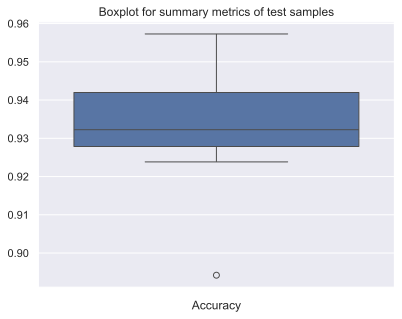

In [75]:
# Plot the cross validation score (accuracy) in the Grid Search
cv_errors = np.empty([nFolds,len(RFE_fit.cv_results_['split0_test_score'])])
for split in range(nFolds):
    cv_errors[split,:] = RFE_fit.cv_results_['split' + str(split) + '_test_score']
meanAcc = cv_errors.mean(0)
stdAcc = cv_errors.std(0)

scores_RFE = meanAcc # Store cv-scores for later

ax = sns.boxplot(y=cv_errors.squeeze()).set_title('Boxplot for summary metrics of test samples')
plt.xlabel('Accuracy')
plt.show()

In [75]:

#Recursive feature elimination
# Summarize all features
# Obtain the name of all the features used as inputs
inputs = INPUTS_RFE_NUM + INPUTS_RFE_CAT
if X_train.select_dtypes('category').shape[1] > 0:
	input_names = []
	for cat_input in X_train.select_dtypes('category').columns:
		input_names += [cat_input + str(cat) for cat in X_train[cat_input].unique()]
	coefnames = X_train.select_dtypes(exclude='category').columns.values.tolist() + input_names
else:
	coefnames = X_train.columns.values.tolist()

for i in range(len(coefnames)):
	print('Column: %s, Selected %s, Rank: %.3f' % (coefnames[i], RFE_fit.best_estimator_.named_steps['selector'].support_[i], RFE_fit.best_estimator_.named_steps['selector'].ranking_[i]))


# El rank indica en qué iteración se eliminó una característica. Si una variable tiene rank=1, significa que esa variable nunca fue 
# eliminada porque es considerada importante. Si una variable tiene un rank mayor (por ejemplo, rank=2), significa que fue eliminada en 
# la segunda iteración del proceso de RFE.


Column: TMAX230, Selected True, Rank: 1.000
Column: TMAX229, Selected True, Rank: 1.000
Column: TMAX237, Selected True, Rank: 1.000
Column: TMAX417, Selected False, Rank: 2.000
Column: TMAX2969, Selected True, Rank: 1.000
Column: TMAX3910, Selected True, Rank: 1.000
Column: TMAX3918, Selected True, Rank: 1.000
Column: TMAX3959, Selected True, Rank: 1.000
Column: WEEKDAY2, Selected True, Rank: 1.000
Column: WEEKDAY7, Selected True, Rank: 1.000
Column: WEEKDAY6, Selected True, Rank: 1.000
Column: WEEKDAY5, Selected True, Rank: 1.000
Column: WEEKDAY4, Selected True, Rank: 1.000
Column: WEEKDAY1, Selected True, Rank: 1.000
Column: WEEKDAY3, Selected True, Rank: 1.000
Column: MONTH9, Selected True, Rank: 1.000
Column: MONTH8, Selected True, Rank: 1.000
Column: MONTH5, Selected True, Rank: 1.000
Column: MONTH4, Selected True, Rank: 1.000
Column: MONTH6, Selected True, Rank: 1.000
Column: MONTH2, Selected True, Rank: 1.000
Column: MONTH1, Selected True, Rank: 1.000
Column: MONTH11, Selected T

In [81]:
# Obtener el preprocesamiento transformado
preprocessor = RFE_fit.best_estimator_.named_steps['preprocessor']

# Transformar los datos de entrenamiento para obtener las columnas correctamente codificadas
X_train_transformed = preprocessor.transform(X_train)

# Obtener los nombres de las columnas después del preprocesamiento
# Para las variables numéricas y categóricas
coefnames = preprocessor.get_feature_names_out()

# Ahora la longitud de coefnames debería coincidir con el número de columnas después del preprocesamiento
# Mostrar las columnas seleccionadas
selected_features = [coefnames[i] for i in range(RFE_fit.best_estimator_.named_steps['selector'].support_.shape[0]) if RFE_fit.best_estimator_.named_steps['selector'].support_[i]]

# Mostrar las características seleccionadas
print("Selected features:")
print(selected_features)

Selected features:
['num__TMAX230', 'num__TMAX237', 'num__TMAX3910', 'num__TMAX3918', 'num__TMAX3959', 'cat__WEEKDAY_1', 'cat__WEEKDAY_2', 'cat__WEEKDAY_3', 'cat__WEEKDAY_4', 'cat__WEEKDAY_5', 'cat__WEEKDAY_6', 'cat__WEEKDAY_7', 'cat__MONTH_1', 'cat__MONTH_2', 'cat__MONTH_3', 'cat__MONTH_4', 'cat__MONTH_5', 'cat__MONTH_6', 'cat__MONTH_7', 'cat__MONTH_8', 'cat__MONTH_9', 'cat__MONTH_10', 'cat__MONTH_11', 'cat__MONTH_12']


In [83]:
# Identify correlated variables
X_processed = RFE_fit.best_estimator_[0].transform(X_train)
X_processed = X_processed[:,RFE_fit.best_estimator_.named_steps['selector'].support_]
#Identify correlated variables
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_processed, i) for i in range(X_processed.shape[1])]
vif["features"] = [coefnames[i] for i in range(RFE_fit.best_estimator_.named_steps['selector'].support_.shape[0]) if RFE_fit.best_estimator_.named_steps['selector'].support_[i]]
vif.round(1)
# there is multicolinearity present in the model for input TMAX3918

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF Factor,features
0,9.3,num__TMAX230
1,6.8,num__TMAX237
2,4.4,num__TMAX3910
3,12.1,num__TMAX3918
4,3.7,num__TMAX3959
5,inf,cat__WEEKDAY_1
6,inf,cat__WEEKDAY_2
7,inf,cat__WEEKDAY_3
8,inf,cat__WEEKDAY_4
9,inf,cat__WEEKDAY_5


In [85]:
dfTR_eval['RFE_pred'] = RFE_fit.predict(X_train)
dfTS_eval['RFE_pred'] = RFE_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['RFE_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['RFE_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['RFE_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['RFE_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['RFE_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['RFE_pred']))

Training MAE: 1.3906424405824689
Test MAE: 1.4818031764933937
Training RMSE: 1.7362667894923884
Test RMSE: 1.8103279964141579
Training R2: 0.9388151354461871
Test R2: 0.9276890682769644


#### Ridge regression

In [87]:
# Este código nos permite analizar cómo los coeficientes del modelo evolucionan a medida que se ajusta el parámetro alpha. 
# Podemos usar estos coeficientes para generar gráficos o análisis sobre la relación entre el valor de alpha y los coeficientes del modelo.

## Inputs of the model. Change accordingly to perform variable selection
INPUTS_Ridge_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_Ridge_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_Ridge = INPUTS_Ridge_NUM + INPUTS_Ridge_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_Ridge_NUM),
        ('cat', categorical_transformer, INPUTS_Ridge_CAT)
        ])

#Penalilizacion que queremos para el Ridge
param = {'Ridge_model__alpha':np.logspace(-5, 5, 20)} #de 10^-5 a 10^5 con un total de 20 puntos
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('Ridge_model', Ridge())
        ])
# As we want to know how the coefficients evolve with alpha, we have to do the grid ourselves first
nFolds = 10
coefs = []

#Para cada \alpha, adju
for alpha in param['Ridge_model__alpha']:
    param_iter = {'Ridge_model__alpha': [alpha]}
    Ridge_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                        param_grid=param_iter, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize)
                        scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 
    Ridge_fit.fit(X_train[INPUTS_Ridge], y_train) # Search in grid
    coefs.append(Ridge_fit.best_estimator_[1].coef_)

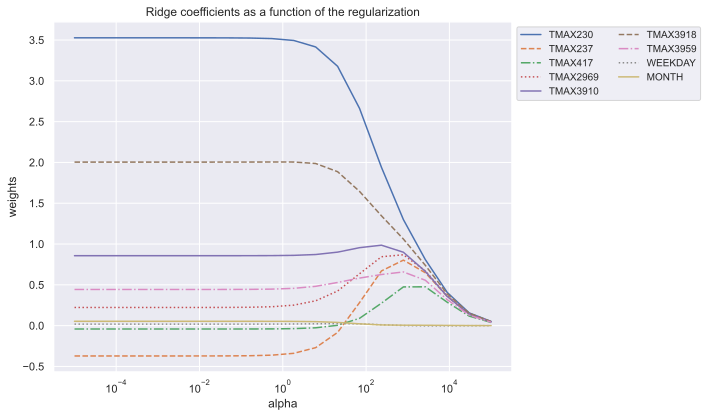

In [89]:
# Define different line styles to cycle through
line_styles = ['-', '--', '-.', ':']

# Plot evolution of coefficients with different values of alpha
plt.figure(figsize=(10, 6))

# Plot each coefficient line with different colors and line styles
for i in range(len(INPUTS_Ridge)):
    plt.plot(
        param['Ridge_model__alpha'], 
        [coef[i] for coef in coefs], 
        label=INPUTS_Ridge[i], 
        linestyle=line_styles[i % len(line_styles)]  # Cycle through line styles
    )

# Set the scale of the x-axis to logarithmic
plt.xscale('log')

# Add labels and title
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')

# Add a legend to identify each variable
plt.legend(loc='best', fontsize='small', ncol=2, bbox_to_anchor=(1, 1))

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


In [93]:
# Este código está diseñado para encontrar el mejor valor de alpha de manera eficiente sin necesidad de almacenar los coeficientes para 
# cada valor. El objetivo aquí es simplemente optimizar alpha y encontrar el modelo más adecuado.

# Train the model with the whole grid in order to obtain the cross validation errors easily
Ridge_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
Ridge_fit.fit(X_train[INPUTS_Ridge], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('Ridge_model', Ridge())]),
             n_...
             param_grid={'Ridge_model__alpha': array([1.00000000e-05, 3.35981829e-05, 1.12883789e-04, 3.79269019e-04,
       1.27427499e-03, 4.28133240e-03, 1.43844989e-02, 4.83293024e-02,
       1.62377674e-01, 5.45559478e-01, 1.83298071e+00, 6.15848211e+00,
       2.06913808e+01, 6.95192796e+01, 2.33572147e+02, 7.84759970e+02,
       2.63665090e+03, 8.85866790e+03, 2.97635144e+04, 1.00000000e+05])},
             scoring='neg_mean_squared_error')

In [103]:
def plotModelGridError(model, figsize=(12, 6), xscale:str="linear", xscale2:str="linear", param1:str=None, param2:str=None):
    """Plot model cross-validation error along grid of hyperparameters

    Args:
        model: model to analyze
        figsize (tuple[float, float], optional): figure of plot size. Defaults to (12, 6).
        xscale (str, optional): Scale of x-axis of first plot. Defaults to "linear".
        xscale2 (str, optional): Scale of x-axis of second plot. Defaults to "linear".
        param1 (str, optional): First parameter of the grid to analyze. Defaults to None.
        param2 (str, optional): Second parameter of the grid to analyze. Defaults to None.

    Raises:
        TypeError: No hyperparameters found in grid, grid must have some hyperparameter to create plot
    """
    cv_r = model.cv_results_
    err = cv_r["mean_test_score"]
    std = cv_r["std_test_score"]
    param_names = list(model.cv_results_.keys())
    if param1 is not None and param2 is not None:
        param_names = ["param_"+param1, "param_"+param2]
    param_keys = [s for s in param_names if "param_" in s]
    params = [s.split("param_")[1] for s in param_keys]
        
    best_params = model.best_params_
    if not param_keys:
        raise TypeError("No hyperparameters encountered in grid.")
    if len(param_keys) > 1:
        grid1 = model.cv_results_[param_keys[0]].data
        cat1 = 'num'
        if not(type(grid1[0]) == int or type(grid1[0]) == float):
            grid1 = [p for p in list(grid1)]
            cat1 = 'cat'
        param_name1 = " ".join(params[0].split("__")[1].split("_"))
        grid2 = model.cv_results_[param_keys[1]].data
        cat2 = 'num'
        if not(type(grid2[0]) == int or type(grid2[0]) == float):
            grid2 = [p  for p in list(grid2)]
            cat2 = 'cat'
        param_name2 = " ".join(params[1].split("__")[1].split("_"))

        cols        = ['cv_error', 'cv_std']
        multi_index = pd.MultiIndex.from_tuples([(p1, p2) for p1, p2 in sorted(zip(grid1, grid2))], names=[param1, param2])
        dfe         = pd.DataFrame([(e, s) for e, s in zip(err, std)], columns=cols, index=multi_index)
        # First hyperparameter
        plt.figure(figsize=figsize)
        ax = plt.gca()
        dfe.unstack(level=1)['cv_error'].plot(ax=ax, style='o-', yerr=dfe.unstack(level=1)['cv_std'])
        #reset color cycle so that the marker colors match
        ax.set_prop_cycle(None)
        #plot the markers
        sc = dfe.unstack(level=1)['cv_error'].plot(figsize=(12,8), style='o-', markersize=5, ax=ax)
        handles, labels = ax.get_legend_handles_labels()
        handles = handles[0:int(len(labels)/2)]
        labels = labels[0:int(len(labels)/2)]
        ax.legend(handles,labels,loc="lower right", title=param_name2)
        if not cat1 == 'cat':
            plt.plot(model.best_params_[params[0]], model.best_score_, marker="o", markersize=15, color="red")
        else:
            pos = list(dfe.unstack(level=1).index).index(model.best_params_[params[0]])
            plt.plot(pos, model.best_score_, marker="o", markersize=15, color="red")
        plt.title(f"Best model with {params[0]} = {str(best_params[params[0]])} and {params[1]} = {str(best_params[params[1]])} ")
        plt.xlabel(param_name1)
        plt.xscale(xscale)
        plt.show()
        # Second hyperparameter
        plt.figure(figsize=figsize)
        dfe.unstack(level=0)['cv_error'].plot(ax=plt.gca(), style='o-', yerr=dfe.unstack(level=1)['cv_std'])
        #reset color cycle so that the marker colors match
        plt.gca().set_prop_cycle(None)
        #plot the markers
        dfe.unstack(level=0)['cv_error'].plot(figsize=(12,8), style='o-', markersize=5, ax = plt.gca())
        handles, labels = plt.gca().get_legend_handles_labels()
        handles = handles[0:int(len(labels)/2)]
        labels = labels[0:int(len(labels)/2)]
        plt.gca().legend(handles,labels,loc="lower right", title=param_name1)
        if not cat2 == 'cat':
            plt.plot(model.best_params_[params[1]], model.best_score_, marker="o", markersize=15, color="red")
        else:
            pos = list(dfe.unstack(level=0).index).index(model.best_params_[params[1]])
            plt.plot(pos, model.best_score_, marker="o", markersize=15, color="red")
        plt.title(f"Best model with {params[0]} = {str(best_params[params[0]])} and {params[1]} = {str(best_params[params[1]])} ")
        plt.xlabel(param_name2)
        plt.xscale(xscale2)
        plt.show()
    else:
        grid=model.cv_results_[param_keys[0]].data
        if not(type(grid[0]) == int or type(grid[0]) == float):
            grid = [p for p in list(grid)]
        param_name= " ".join(params[0].split("__")[1].split("_"))
        
        plt.figure(figsize=figsize)
        plt.errorbar(grid, err, yerr=std, linestyle="None", ecolor='lightblue')
        plt.plot(grid, err, marker="o", markersize=10, c='lightblue')
        plt.plot(model.best_params_[params[0]], model.best_score_, marker="o", markersize=15, color="red")
        plt.title(f"Best model with {params[0]} = {str(best_params[params[0]])} ")
        plt.xlabel(param_name)
        plt.xscale(xscale)
        plt.show()
    return


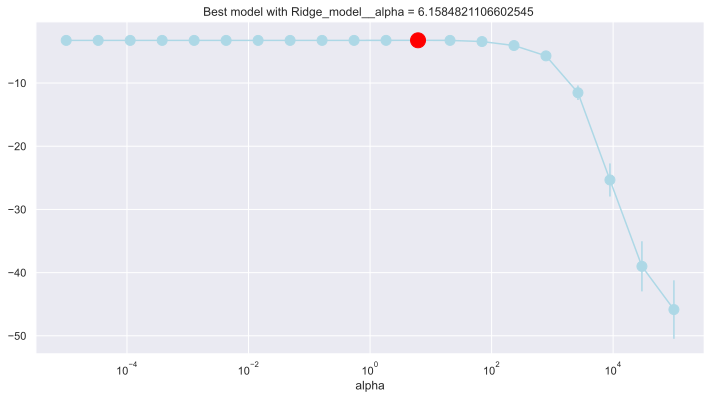

In [105]:
plotModelGridError(Ridge_fit, xscale="log")

In [107]:
dfTR_eval['Ridge_pred'] = Ridge_fit.predict(X_train)
dfTS_eval['Ridge_pred'] = Ridge_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['Ridge_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['Ridge_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['Ridge_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['Ridge_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['Ridge_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['Ridge_pred']))

Training MAE: 1.390109659279812
Test MAE: 1.4874711641158853
Training RMSE: 1.7366647315986399
Test RMSE: 1.8162212743844983
Training R2: 0.9387870858120738
Test R2: 0.927217505050786


#### Lasso regression

In [119]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_Lasso_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_Lasso_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_Lasso = INPUTS_Lasso_NUM + INPUTS_Lasso_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_Lasso_NUM),
        ('cat', categorical_transformer, INPUTS_Lasso_CAT)
        ])

param = {'Lasso_model__alpha':np.logspace(-5, 5, 20)} 
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('Lasso_model', Lasso())
        ])
# As we want to know how the coefficients evolve with alpha, we have to do the grid ourselves first
nFolds = 10
coefs = []
for alpha in param['Lasso_model__alpha']:
    param_iter = {'Lasso_model__alpha': [alpha]}
    Lasso_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                        param_grid=param_iter, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize)
                        scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 
    Lasso_fit.fit(X_train[INPUTS_Lasso], y_train) # Search in grid
    coefs.append(Lasso_fit.best_estimator_[1].coef_)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.145e+01, tolerance: 3.554e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.812e+01, tolerance: 3.532e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.243e+01, toler

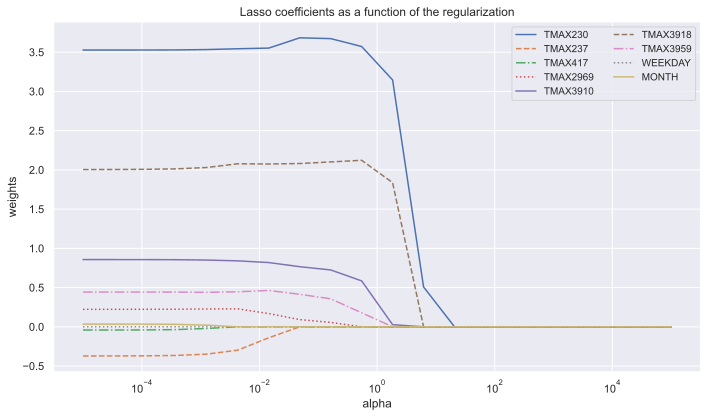

In [121]:
# Define different line styles to cycle through
line_styles = ['-', '--', '-.', ':']

# Plot evolution of coefficients with different values of alpha
plt.figure(figsize=(10, 6))

# Plot each coefficient line with different colors and line styles
for i in range(len(INPUTS_Lasso)):
    plt.plot(
        param['Lasso_model__alpha'], 
        [coef[i] for coef in coefs], 
        label=INPUTS_Lasso[i], 
        linestyle=line_styles[i % len(line_styles)]  # Cycle through line styles
    )

# Set the scale of the x-axis to logarithmic
plt.xscale('log')

# Add labels and title
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Lasso coefficients as a function of the regularization')

# Add a legend to identify each variable
plt.legend(loc='best', fontsize='small', ncol=2, bbox_to_anchor=(1, 1))

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()
# Variables significativas: Las variables como "TMAX230", "TMAX3918", "TMAX237", que mantienen coeficientes grandes incluso con un alpha 
# elevado, son importantes para el modelo, y el Lasso las retiene porque son útiles para la predicción.
# Variables irrelevantes: Variables como "TMAX417", "WEEKDAY", "MONTH", cuyos coeficientes se reducen a cero rápidamente a medida que 
# alpha aumenta, probablemente no tienen un impacto significativo en el modelo. Esto sugiere que el modelo puede prescindir de ellas 
# sin perder precisión.


In [123]:
# Train the model with the whole grid in order to obtain the cross validation errors easily
Lasso_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
Lasso_fit.fit(X_train[INPUTS_Lasso], y_train) # Search in grid

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.145e+01, tolerance: 3.554e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.812e+01, tolerance: 3.532e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.243e+01, toler

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('Lasso_model', Lasso())]),
             n_...
             param_grid={'Lasso_model__alpha': array([1.00000000e-05, 3.35981829e-05, 1.12883789e-04, 3.79269019e-04,
       1.27427499e-03, 4.28133240e-03, 1.43844989e-02, 4.83293024e-02,
       1.62377674e-01, 5.45559478e-01, 1.83298071e+00, 6.15848211e+00,
       2.06913808e+01, 6.95192796e+01, 2.33572147e+02, 7.84759970e+02,
       2.63665090e+03, 8.85866790e+03, 2.97635144e+04, 1.00000000e+05])},
             scoring='neg_mean_squared_error')

In [125]:
coefs_lasso = pd.DataFrame(Lasso_fit.best_estimator_[1].coef_, index=Lasso_fit.best_estimator_[0].get_feature_names_out(), columns=['Coefs'])
coefs_lasso['Selected'] = coefs_lasso['Coefs'] != 0
coefs_lasso

,Coefs,Selected
num__TMAX230,3.552306,True
num__TMAX237,-0.139519,True
num__TMAX417,0.000000,False
num__TMAX2969,0.168706,True
num__TMAX3910,0.818789,True
num__TMAX3918,2.075111,True
num__TMAX3959,0.463398,True
cat__WEEKDAY_1,0.000000,False
cat__WEEKDAY_2,0.000000,False
cat__WEEKDAY_3,0.000000,False


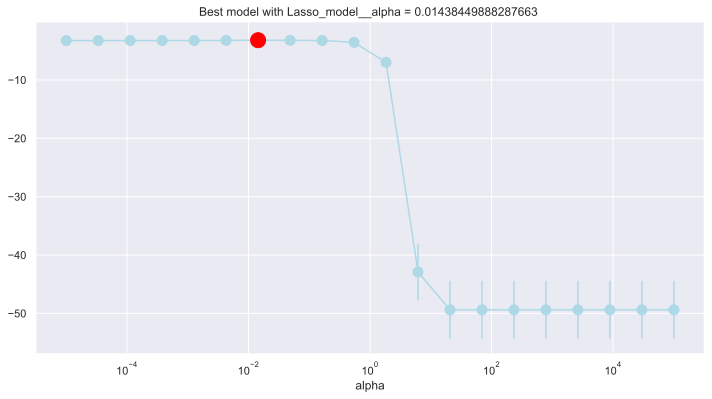

In [127]:
plotModelGridError(Lasso_fit, xscale='log')

In [129]:
dfTR_eval['Lasso_pred'] = Lasso_fit.predict(X_train)
dfTS_eval['Lasso_pred'] = Lasso_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['Lasso_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['Lasso_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['Lasso_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['Lasso_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['Lasso_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['Lasso_pred']))

Training MAE: 1.391582477147919
Test MAE: 1.4883184306425035
Training RMSE: 1.7458032992502495
Test RMSE: 1.8241970473056706
Training R2: 0.9381411693462915
Test R2: 0.926576865873101


#### ElasticNet Regression

In [131]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_ENet_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_ENet_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_ENet = INPUTS_ENet_NUM + INPUTS_ENet_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_ENet_NUM),
        ('cat', categorical_transformer, INPUTS_ENet_CAT)
        ])

param = {'ElasticNet_model__alpha':np.logspace(-5, 5, 20)} 
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('ElasticNet_model', ElasticNet())
        ])
# As we want to know how the coefficients evolve with alpha, we have to do the grid ourselves first
nFolds = 10
coefs = []
for alpha in param['ElasticNet_model__alpha']:
    param_iter = {'ElasticNet_model__alpha': [alpha]}
    ElasticNet_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                        param_grid=param_iter, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize)
                        scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 
    ElasticNet_fit.fit(X_train[INPUTS_ENet], y_train) # Search in grid
    coefs.append(ElasticNet_fit.best_estimator_[1].coef_)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.019e+01, tolerance: 3.554e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.494e+01, tolerance: 3.525e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.242e+02, toler

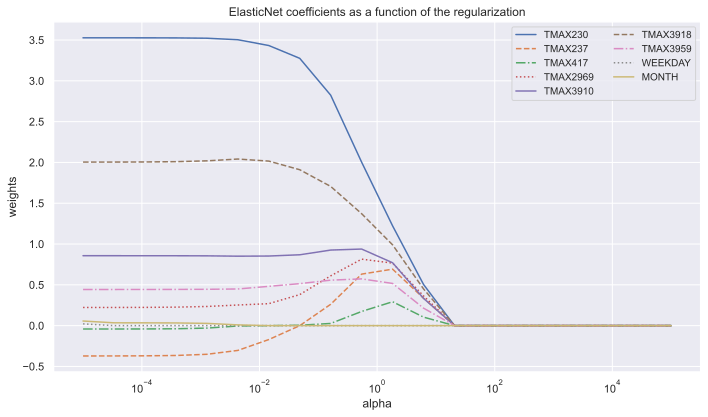

In [133]:
# Define different line styles to cycle through
line_styles = ['-', '--', '-.', ':']

# Plot evolution of coefficients with different values of alpha
plt.figure(figsize=(10, 6))

# Plot each coefficient line with different colors and line styles
for i in range(len(INPUTS_ENet)):
    plt.plot(
        param['ElasticNet_model__alpha'], 
        [coef[i] for coef in coefs], 
        label=INPUTS_ENet[i], 
        linestyle=line_styles[i % len(line_styles)]  # Cycle through line styles
    )

# Set the scale of the x-axis to logarithmic
plt.xscale('log')

# Add labels and title
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('ElasticNet coefficients as a function of the regularization')

# Add a legend to identify each variable
plt.legend(loc='best', fontsize='small', ncol=2, bbox_to_anchor=(1, 1))

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


In [135]:
# Train the model with the whole grid in order to obtain the cross validation errors easily
ElasticNet_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
ElasticNet_fit.fit(X_train[INPUTS_ENet], y_train) # Search in grid

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.019e+01, tolerance: 3.554e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.242e+02, tolerance: 3.532e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.494e+01, toler

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('ElasticNet_model', ElasticN...
             param_grid={'ElasticNet_model__alpha': array([1.00000000e-05, 3.35981829e-05, 1.12883789e-04, 3.79269019e-04,
       1.27427499e-03, 4.28133240e-03, 1.43844989e-02, 4.83293024e-02,
       1.62377674e-01, 5.45559478e-01, 1.83298071e+00, 6.15848211e+00,
       2.06913808e+01, 6.95192796e+01, 2.33572147e+02, 7.84759970e+02,
       2.63665090e+03, 8.85866790e+03, 2.97635144e+04, 1.00000000e+05])},
             scoring='neg_mean_squared_error')

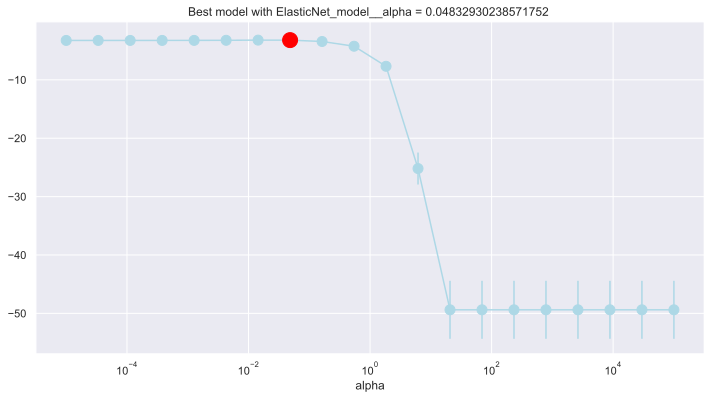

In [137]:
plotModelGridError(ElasticNet_fit, xscale='log')

In [139]:
dfTR_eval['ElasticNet_pred'] = ElasticNet_fit.predict(X_train)
dfTS_eval['ElasticNet_pred'] = ElasticNet_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['ElasticNet_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['ElasticNet_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['ElasticNet_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['ElasticNet_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['ElasticNet_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['ElasticNet_pred']))

Training MAE: 1.4062613253312428
Test MAE: 1.501951835614486
Training RMSE: 1.762878536341978
Test RMSE: 1.8445984935747448
Training R2: 0.9369252022661668
Test R2: 0.9249253837103946


#### Principal Components Regression

In [141]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_PCR_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_PCR_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_PCR = INPUTS_PCR_NUM + INPUTS_PCR_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_PCR_NUM),
        ('cat', categorical_transformer, INPUTS_PCR_CAT)
        ])

# Obtain names of the inputs
if X_train.select_dtypes('category').shape[1] > 0:
    input_names = []
    for cat_input in X_train.select_dtypes('category').columns:
        input_names += [cat_input + str(cat) for cat in X_train[cat_input].unique()]
    coefnames = X_train.select_dtypes(exclude='category').columns.values.tolist() + input_names
else:
    coefnames = X_train.columns.values.tolist()
    
param = {'pca__n_components': range(1,len(coefnames))} 
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('pca', PCA()),
            ('LR_model', LinearRegression(fit_intercept=True))
        ])

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
PCR_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
PCR_fit.fit(X_train[INPUTS_PCR], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('pca', PCA()),
                                       ('LR_model', LinearRegression())]),
             n_jobs=-1, param_grid={'pca__n_components': range(1, 26)},
             scoring='neg_mean_squared_error')

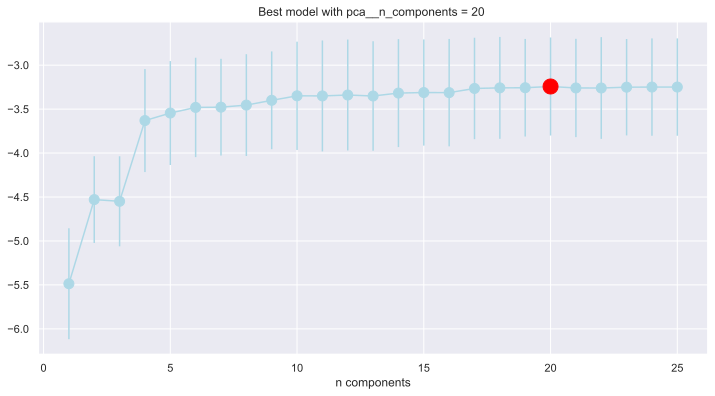

In [143]:
plotModelGridError(PCR_fit)

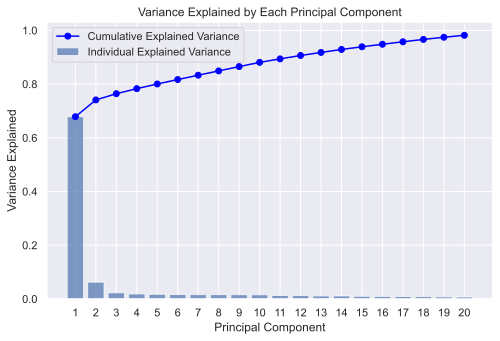

In [145]:
# Extract the PCA object from the best estimator of your GridSearchCV result
pca = PCR_fit.best_estimator_.named_steps['pca']

# Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative variance
cumulative_variance = explained_variance_ratio.cumsum()

# Create a range for the number of components
n_components_range = range(1, len(explained_variance_ratio) + 1)

# Plotting
plt.figure(figsize=(8, 5))

# Bar plot for individual explained variance
plt.bar(n_components_range, explained_variance_ratio, alpha=0.7, align='center', label='Individual Explained Variance')

# Line plot for cumulative explained variance
plt.plot(n_components_range, cumulative_variance, marker='o', linestyle='-', color='blue', label='Cumulative Explained Variance')

# Adding labels and title
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each Principal Component')
plt.xticks(n_components_range)

# Adding legend
plt.legend()

# Show plot
plt.show()

In [147]:
# Print the PCs
loadings = pd.DataFrame(PCR_fit.best_estimator_[1].components_.T * np.sqrt(PCR_fit.best_estimator_[1].explained_variance_), columns=['PC' + str(pca + 1) for pca in range(PCR_fit.best_params_['pca__n_components'])], index=coefnames)
loadings

# Valores de la tabla (pesos): Los valores en la tabla, llamados loadings o cargas, indican cuánto contribuye cada variable original al 
# componente principal correspondiente. Los valores altos en una columna indican que la variable tiene un mayor peso en ese componente 
# principal. Los valores cercanos a cero indican que la variable tiene poca influencia en ese componente.

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
TMAX230,0.928825,-0.204707,-0.051564,0.244435,-0.022465,-0.087045,-0.006585,0.030158,-0.033834,0.098621,0.023149,0.053041,-0.007489,0.028049,-0.007169,0.008249,-0.010044,0.025839,-0.001140,-0.054843
TMAX237,0.937167,-0.167505,-0.105897,-0.124572,0.050786,0.044550,-0.016279,-0.021211,0.028561,-0.028977,0.154452,-0.151274,-0.055139,0.006982,-0.015242,-0.037976,0.060400,0.038801,0.022200,-0.054175
TMAX417,0.850900,0.485594,0.031273,-0.062252,-0.016061,-0.040230,-0.004645,-0.007050,0.012353,0.002076,0.074427,0.102963,0.015327,-0.031903,-0.002080,0.030090,-0.042492,-0.018063,0.072409,-0.090072
TMAX2969,0.941960,-0.163815,-0.110710,-0.150590,-0.024705,0.009092,0.022986,0.006170,0.003881,-0.058610,-0.087029,0.126320,0.009120,0.004868,0.021962,-0.007400,0.019540,-0.084094,-0.095330,0.021213
TMAX3910,0.904083,-0.148960,0.396073,-0.016193,-0.007364,0.023352,0.009021,-0.027526,0.002805,-0.009170,-0.004131,-0.015336,0.012864,0.005401,-0.030888,0.012829,0.022816,-0.002716,-0.001716,0.028036
TMAX3918,0.960146,-0.128145,-0.091362,-0.000423,0.001389,0.022981,-0.006266,-0.000221,0.005580,-0.028651,-0.076136,-0.011281,0.046133,-0.043940,0.039176,0.038767,-0.114676,0.030643,0.093394,0.063643
TMAX3959,0.888601,0.394061,-0.041418,0.110326,0.019429,0.022084,0.000126,0.020392,-0.019542,0.023668,-0.077014,-0.099530,-0.020374,0.029307,-0.007084,-0.038707,0.075512,0.012483,-0.097166,0.070966
WEEKDAY2,-0.007784,-0.001752,-0.006200,-0.008822,-0.062122,-0.138681,-0.251033,-0.177333,0.012569,-0.044848,-0.028940,-0.018057,0.007624,0.007145,0.001809,-0.000248,0.015301,-0.002626,-0.010139,0.003629
WEEKDAY7,0.007799,0.003152,-0.018726,-0.072604,-0.083339,-0.118688,0.242861,-0.128962,-0.045419,0.115704,-0.015101,-0.050183,0.021849,0.008831,-0.008312,-0.016095,-0.003157,0.004610,0.005739,0.005835
WEEKDAY6,-0.007060,0.001072,0.015149,0.028652,-0.059114,-0.033212,0.027217,0.148830,-0.218369,-0.204083,0.030314,-0.019420,-0.012986,-0.013463,-0.000374,-0.002680,0.000597,0.005164,0.006015,-0.010583


/var/folders/6r/17dbwpxj45s03vzxrc5kddj40000gn/T/ipykernel_13171/1250446040.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/6r/17dbwpxj45s03vzxrc5kddj40000gn/T/ipykernel_13171/1250446040.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/6r/17dbwpxj45s03vzxrc5kddj40000gn/T/ipykernel_13171/1250446040.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


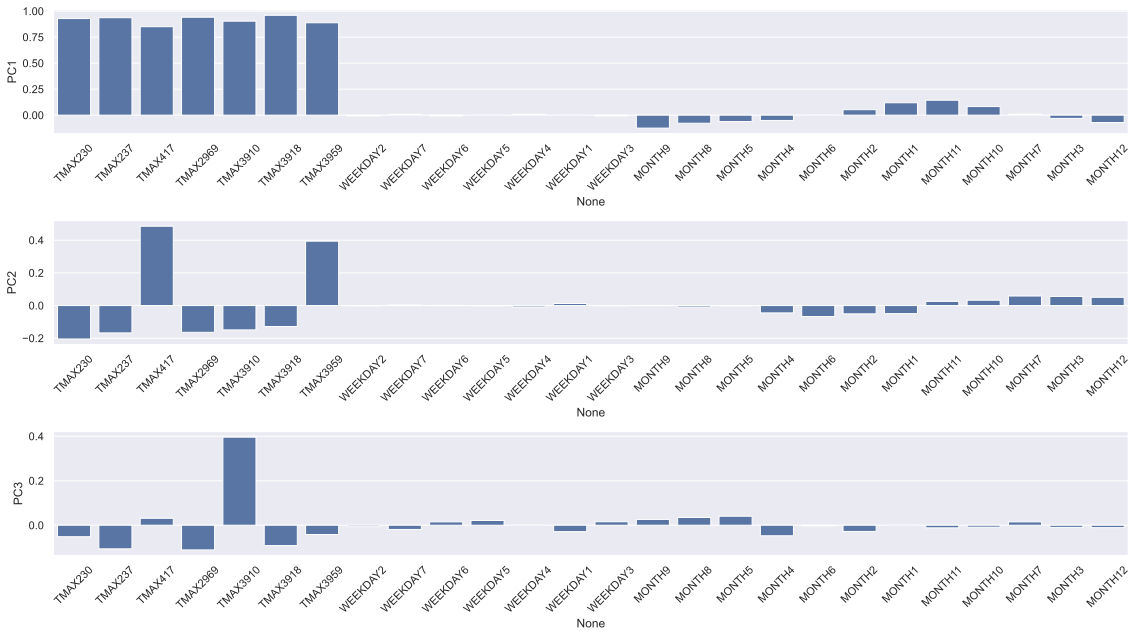

In [149]:
# Plot the 3 first PCs
# fig, axes = plt.subplots(loadings.shape[1], 1, figsize=(16,9))
fig, axes = plt.subplots(3, 1, figsize=(16, 9))
PC = 0
for ax in axes.ravel():
    sns.barplot(data=loadings, x=loadings.index, y=loadings.columns.values.tolist()[PC], ax=ax)
    
    # Rotate x-axis labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    PC += 1

plt.tight_layout()  # Adjust the layout so the labels fit into the figure area
plt.show()

In [151]:
dfTR_eval['PCR_pred'] = PCR_fit.predict(X_train)
dfTS_eval['PCR_pred'] = PCR_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['PCR_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['PCR_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['PCR_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['PCR_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['PCR_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['PCR_pred']))

Training MAE: 1.4061143472681545
Test MAE: 1.499974944036033
Training RMSE: 1.747473570907829
Test RMSE: 1.820908033406046
Training R2: 0.9380227476694563
Test R2: 0.9268413899353087


#### Partial Least Square Regression

In [153]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_PLSR_NUM = X_train.select_dtypes(include=['int64','float64']).columns.values.tolist()
INPUTS_PLSR_CAT = X_train.select_dtypes(include=['category']).columns.values.tolist()
INPUTS_PLSR = INPUTS_PLSR_NUM + INPUTS_PLSR_CAT

# Prepare the numeric variables by imputing by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, INPUTS_PLSR_NUM),
        ('cat', categorical_transformer, INPUTS_PLSR_CAT)
        ])

# Obtain names of the inputs
if X_train.select_dtypes('category').shape[1] > 0:
    input_names = []
    for cat_input in X_train.select_dtypes('category').columns:
        input_names += [cat_input + str(cat) for cat in X_train[cat_input].unique()]
    coefnames = X_train.select_dtypes(exclude='category').columns.values.tolist() + input_names
else:
    coefnames = X_train.columns.values.tolist()
param = {'PLSR_model__n_components': range(1,len(coefnames))} 
pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('PLSR_model', PLSRegression())
        ])

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
PLSR_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='neg_mean_squared_error', # Negative RMSE https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
PLSR_fit.fit(X_train[INPUTS_PLSR], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['TMAX230',
                                                                          'TMAX237',
                                                                          'TMAX417',
                                                                          'TMAX2969',
                                                                          'TMAX3910',
                                                                          'TMAX3918',
                                                                          'TMAX3959']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['WEEKDAY',
                                                                          'MONTH'])])),
                                       ('PLSR_model', PLSRegression())]),
             n_jobs=-1, param_grid={'PLSR_model__n_components': range(1, 26)},
             scoring='neg_mean_squared_error')

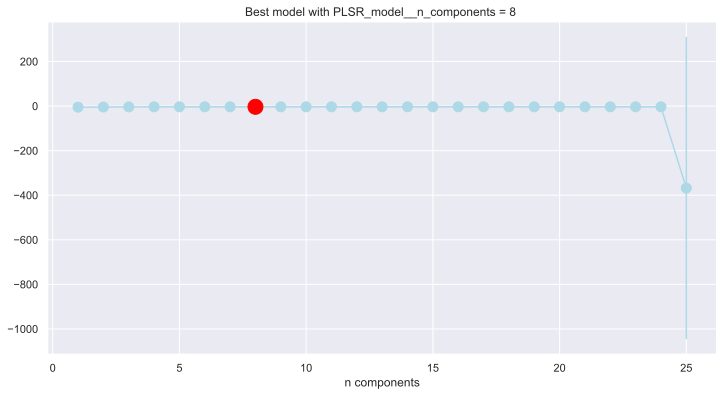

In [155]:
plotModelGridError(PLSR_fit)

In [157]:
dfTR_eval['PLSR_pred'] = PLSR_fit.predict(X_train)
dfTS_eval['PLSR_pred'] = PLSR_fit.predict(X_test)
#Training and test MAE - Mean Absolute error
print('Training MAE:',mean_absolute_error(dfTR_eval['TMIN230'], dfTR_eval['PLSR_pred']))
print('Test MAE:',mean_absolute_error(dfTS_eval['TMIN230'], dfTS_eval['PLSR_pred']))
#Training and test RMSE - Root Mean Square Error
print('Training RMSE:',math.sqrt(mean_squared_error(dfTR_eval['TMIN230'], dfTR_eval['PLSR_pred'])))
print('Test RMSE:',math.sqrt(mean_squared_error(dfTS_eval['TMIN230'], dfTS_eval['PLSR_pred'])))
#Training and test r^2 
print('Training R2:',r2_score(dfTR_eval['TMIN230'], dfTR_eval['PLSR_pred']))
print('Test R2:',r2_score(dfTS_eval['TMIN230'], dfTS_eval['PLSR_pred']))

Training MAE: 1.385960712646151
Test MAE: 1.482733617633583
Training RMSE: 1.7347990410493632
Test RMSE: 1.8145236151161874
Training R2: 0.9389185366428796
Test R2: 0.9273535040415344


### Compare models

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def dotplot(scores: dict, metric: str):
    """
    Generate a horizontal boxplot to visualize the cross-validation errors of multiple models.

    Args:
        scores (dict): A dictionary where keys represent model names and values are lists 
                       or arrays of cross-validation errors for each model.
        metric (str): Label for the x-axis representing the evaluation metric (e.g., "Mean Squared Error").

    The function creates a horizontal boxplot for each model's cross-validation errors and labels the y-axis 
    with the model names, providing a comparative view of model performance.
    """
    # Convert the dictionary of scores into a DataFrame for easier plotting
    df_scores = pd.DataFrame(scores)
    
    # Melt the DataFrame to have one column for the model and one for the score
    df_scores_melted = df_scores.melt(var_name='Model', value_name=metric)
    
    # Create the boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=metric, y='Model', data=df_scores_melted, orient='h', palette='Set2')
    
    # Add title and labels
    plt.title('Comparison of Cross-Validation Errors by Model')
    plt.xlabel(metric)
    plt.ylabel('Models')
    
    # Show the plot
    plt.tight_layout()
    plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.913e+01, tolerance: 3.212e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.247e+01, tolerance: 3.172e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.422e+01, toler

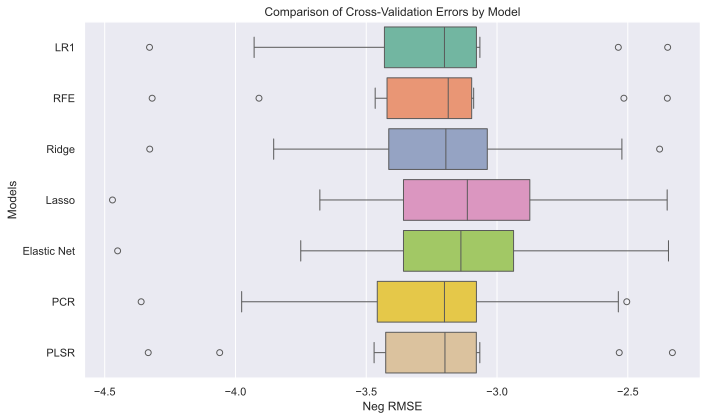

In [161]:
## Compare models
metric = 'Neg RMSE'
score = {'LR1': cross_val_score(LR_fit, X_train[INPUTS_LR], y_train, cv=10, scoring='neg_mean_squared_error'), 
         'RFE': cross_val_score(RFE_fit, X_train[INPUTS_RFE], y_train, cv=10, scoring='neg_mean_squared_error'), 
         'Ridge': cross_val_score(Ridge_fit, X_train[INPUTS_Ridge], y_train, cv=10, scoring='neg_mean_squared_error'), 
         'Lasso': cross_val_score(Lasso_fit, X_train[INPUTS_Lasso], y_train, cv=10, scoring='neg_mean_squared_error'), 
         'Elastic Net': cross_val_score(ElasticNet_fit, X_train[INPUTS_ENet], y_train, cv=10, scoring='neg_mean_squared_error'), 
         'PCR': cross_val_score(PCR_fit, X_train[INPUTS_PCR], y_train, cv=10, scoring='neg_mean_squared_error'), 
         'PLSR': cross_val_score(PLSR_fit, X_train[INPUTS_PLSR], y_train, cv=10, scoring='neg_mean_squared_error')}
dotplot(score, metric)